# Apprentissage non supervisé
# Le clustering : Prédiction du Prix des Voitures

## <font color='red'>1) Le clustering: K-Means</font>

### <font color='red'>  Chargement des données</font>

In [1]:
# Importation de toutes les librairies nécessaires (fait une seule fois)
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Lecture du fichier CSV — pd.read_csv retourne déjà un DataFrame
df = pd.read_csv("car_prices_Pretraite.csv", header=0)

# Afficher les premières lignes pour vérifier le chargement
df.head()

,year,make,model,trim,body,transmission,vin,state,condition,odometer,color,interior,seller,mmr,sellingprice,saledate
0,2015,Kia,Sorento,LX,suv,automatic,5xyktca69fg566472,ca,5.0,16639.0,white,black,kia motors america inc,20500.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
1,2015,Kia,Sorento,LX,suv,automatic,5xyktca69fg561319,ca,5.0,9393.0,white,beige,kia motors america inc,20800.0,21500.0,Tue Dec 16 2014 12:30:00 GMT-0800 (PST)
2,2014,Bmw,3 Series,328i SULEV,sedan,automatic,wba3c1c51ek116351,ca,45.0,1331.0,gray,black,financial services remarketing (lease),31900.0,30000.0,Thu Jan 15 2015 04:30:00 GMT-0800 (PST)
3,2015,Volvo,S60,T5,sedan,automatic,yv1612tb4f1310987,ca,41.0,14282.0,white,black,volvo na rep/world omni,27500.0,27750.0,Thu Jan 29 2015 04:30:00 GMT-0800 (PST)
4,2014,Bmw,6 Series Gran Coupe,650i,sedan,automatic,wba6b2c57ed129731,ca,43.0,2641.0,gray,black,financial services remarketing (lease),66000.0,67000.0,Thu Dec 18 2014 12:30:00 GMT-0800 (PST)


In [2]:
# Afficher les dimensions du DataFrame (lignes, colonnes)
df.shape

(548498, 16)

In [3]:
# Afficher les types de chaque colonne
df.dtypes

year              int64
make             object
model            object
trim             object
body             object
transmission     object
vin              object
state            object
condition       float64
odometer        float64
color            object
interior         object
seller           object
mmr             float64
sellingprice    float64
saledate         object
dtype: object

### Interprétation

Le DataFrame contient **548 498 observations** et **16 variables**. On distingue des variables numériques (`year`, `condition`, `odometer`, `mmr`, `sellingprice`) et des variables catégorielles (`make`, `model`, `body`, `transmission`, `color`, etc.). Aucune valeur manquante n'est présente dans ce jeu de données.

### <font color='red'>  Sélection des variables numériques</font>

In [4]:
# Sélection des deux variables numériques : kilométrage et prix de vente
X = df[['odometer', 'sellingprice']].dropna().values
df2 = pd.DataFrame(X, columns=['odometer', 'sellingprice'])

# Aperçu des données sélectionnées
df2.head()

,odometer,sellingprice
0,16639.0,21500.0
1,9393.0,21500.0
2,1331.0,30000.0
3,14282.0,27750.0
4,2641.0,67000.0


In [5]:
# Ajustement du modèle K-Means avec 3 clusters
# random_state=0 assure la reproductibilité des résultats
kmeans = KMeans(n_clusters=3, random_state=0).fit(X)

# Afficher l'étiquette de cluster assignée à chaque observation
kmeans.labels_

array([0, 0, 0, ..., 0, 0, 0], shape=(548498,), dtype=int32)

In [6]:
# Trier les indices des observations par numéro de cluster
idk = np.argsort(kmeans.labels_)
idk

array([     0, 325435, 325434, ..., 341838, 341832, 248688],
      shape=(548498,))

In [7]:
# Réorganiser le DataFrame selon l'ordre des clusters
# L'index du DataFrame correspond au numéro de cluster
dfk = pd.DataFrame(df2.index[idk], kmeans.labels_[idk])
dfk

,0
0,0
0,325435
0,325434
0,325433
0,325432
...,...
2,341840
2,341839
2,341838
2,341832


In [8]:
# Afficher les coordonnées des centroïdes de chaque cluster
# (valeurs moyennes de odometer et sellingprice par cluster)
kmeans.cluster_centers_

array([[ 32133.88431332,  18193.91244981],
       [173359.22075617,   3653.23489198],
       [ 95800.63227912,   8741.16876082]])

### Interprétation

Avec **K=3**, le modèle K-Means segmente les véhicules en trois groupes distincts selon leur kilométrage et leur prix de vente :
- **Cluster à prix bas** : véhicules très kilométrés vendus à faible prix.
- **Cluster intermédiaire** : véhicules avec un usage modéré et un prix moyen.
- **Cluster à prix élevé** : véhicules récents, peu kilométrés, vendus à prix élevé.

Les centroïdes représentent le profil moyen de chaque cluster.

### <font color='red'>  Méthode du coude : choix de K</font>

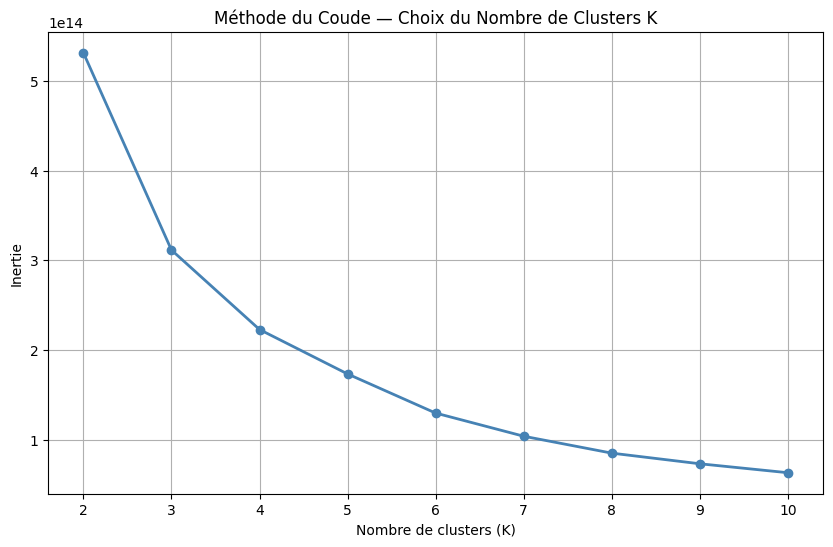

In [9]:
inertias = []
K_range = range(2, 11)

# Calculer l'inertie pour chaque valeur de K
for k in K_range:
    km = KMeans(n_clusters=k, random_state=0, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

# Tracer la courbe d'inertie en fonction de K
plt.figure(figsize=(10, 6))
plt.plot(list(K_range), inertias, marker='o', color='steelblue', linewidth=2)
plt.title("Méthode du Coude — Choix du Nombre de Clusters K")
plt.xlabel("Nombre de clusters (K)")
plt.ylabel("Inertie")
plt.xticks(list(K_range))
plt.grid(True)
plt.show()

### Interprétation

La **méthode du coude** consiste à tracer l'inertie (somme des distances au carré entre chaque point et son centroïde) en fonction du nombre de clusters K. On cherche le point de "coude" où la diminution de l'inertie devient moins prononcée.

D'après la courbe, le coude est visible autour de **K=4**, ce qui signifie qu'augmenter K au-delà de 4 n'apporte pas un gain significatif en termes de compacité des clusters. On retient donc **K=4** pour la suite.

### <font color='red'>  K-Means avec K=4 et visualisation des clusters</font>

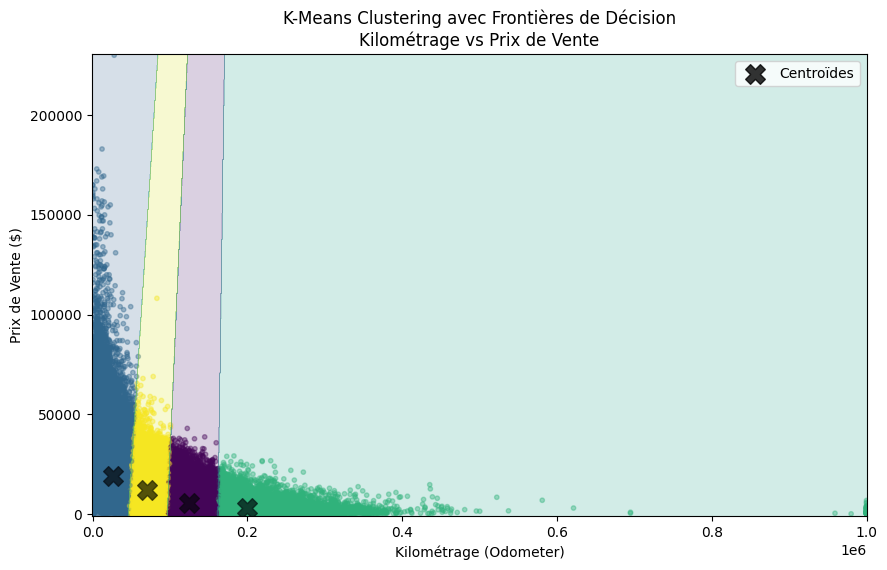

In [10]:
# Appliquer KMeans avec K=4 (valeur retenue par la méthode du coude)
kmeans = KMeans(n_clusters=4, random_state=0, n_init=10)
kmeans.fit(X)
y_kmeans = kmeans.predict(X)

# Tracer les points colorés par cluster
plt.figure(figsize=(10, 6))
plt.scatter(X[:, 0], X[:, 1], c=y_kmeans, s=10, cmap='viridis', alpha=0.4)

# Afficher les centroïdes avec un marqueur distinctif
centers = kmeans.cluster_centers_
plt.scatter(centers[:, 0], centers[:, 1], c='black', s=200, alpha=0.8, marker='X', label='Centroïdes')

# Construire une grille pour tracer les frontières de décision
x_min, x_max = X[:, 0].min() - 1000, X[:, 0].max() + 1000
y_min, y_max = X[:, 1].min() - 1000, X[:, 1].max() + 1000
xx, yy = np.meshgrid(np.arange(x_min, x_max, 500),
                     np.arange(y_min, y_max, 500))
Z = kmeans.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# Afficher les zones colorées correspondant aux frontières
plt.contourf(xx, yy, Z, alpha=0.2, cmap='viridis')
plt.title("K-Means Clustering avec Frontières de Décision\nKilométrage vs Prix de Vente")
plt.xlabel("Kilométrage (Odometer)")
plt.ylabel("Prix de Vente ($)")
plt.legend()
plt.show()

In [11]:
# Trier les indices par numéro de cluster
idk2 = np.argsort(kmeans.labels_)
idk2

array([457272,  94641, 315195, ..., 419205, 419197, 274248],
      shape=(548498,))

In [12]:
# Réorganiser le DataFrame selon les 4 clusters obtenus
df2clust = pd.DataFrame(df2.index[idk2], kmeans.labels_[idk2])
df2clust

,0
0,457272
0,94641
0,315195
0,315194
0,94638
...,...
3,419203
3,419204
3,419205
3,419197


In [13]:
# Coordonnées des centroïdes pour K=4
# Chaque ligne = un cluster, colonnes = odometer et sellingprice
kmeans.cluster_centers_

array([[124426.51167564,   5832.81809369],
       [ 26820.73253301,  19157.37269722],
       [199622.90924488,   3024.88704114],
       [ 70666.8788054 ,  11889.95495765]])

### Interprétation

Le graphique montre clairement **4 segments de marché** pour les véhicules :
- Les **frontières de décision** délimitent les zones d'appartenance à chaque cluster.
- Les **centroïdes** (croix noires) représentent le véhicule "typique" de chaque groupe.
- On observe une relation inverse entre kilométrage et prix : les véhicules les moins kilométrés appartiennent aux clusters à prix élevé, tandis que les véhicules très usés se retrouvent dans les clusters à bas prix.

## <font color='green'>2) Le clustering: Classification Ascendante Hiérarchique</font>

### <font color='green'>  Sélection des données</font>

In [14]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.preprocessing import StandardScaler
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Sous-échantillon de 500 observations pour la lisibilité du dendrogramme
# (la CAH est coûteuse en mémoire sur de grands datasets)
np.random.seed(0)
idx = np.random.choice(len(df), size=500, replace=False)
X_cah = df[['odometer', 'sellingprice']].dropna().iloc[idx].values

df_cah = pd.DataFrame(X_cah, columns=['odometer', 'sellingprice'])

# Normalisation des données avant la CAH
# (indispensable pour éviter qu'une variable domine le calcul des distances)
scaler = StandardScaler()
X_cah_scaled = scaler.fit_transform(X_cah)

df_cah.head()

,odometer,sellingprice
0,66900.0,9700.0
1,24176.0,31600.0
2,133012.0,400.0
3,8725.0,27300.0
4,21325.0,15400.0


### Interprétation

On sélectionne un **sous-échantillon de 500 véhicules** pour deux raisons :
- La CAH construit une **matrice de distances** de taille n×n : sur 548 498 observations, cela serait impossible en mémoire.
- Le dendrogramme resterait illisible avec autant de points.

La **normalisation** est appliquée pour que `odometer` et `sellingprice`, qui ont des échelles très différentes, contribuent équitablement au calcul des distances.

### <font color='green'>  Construction du dendrogramme</font>

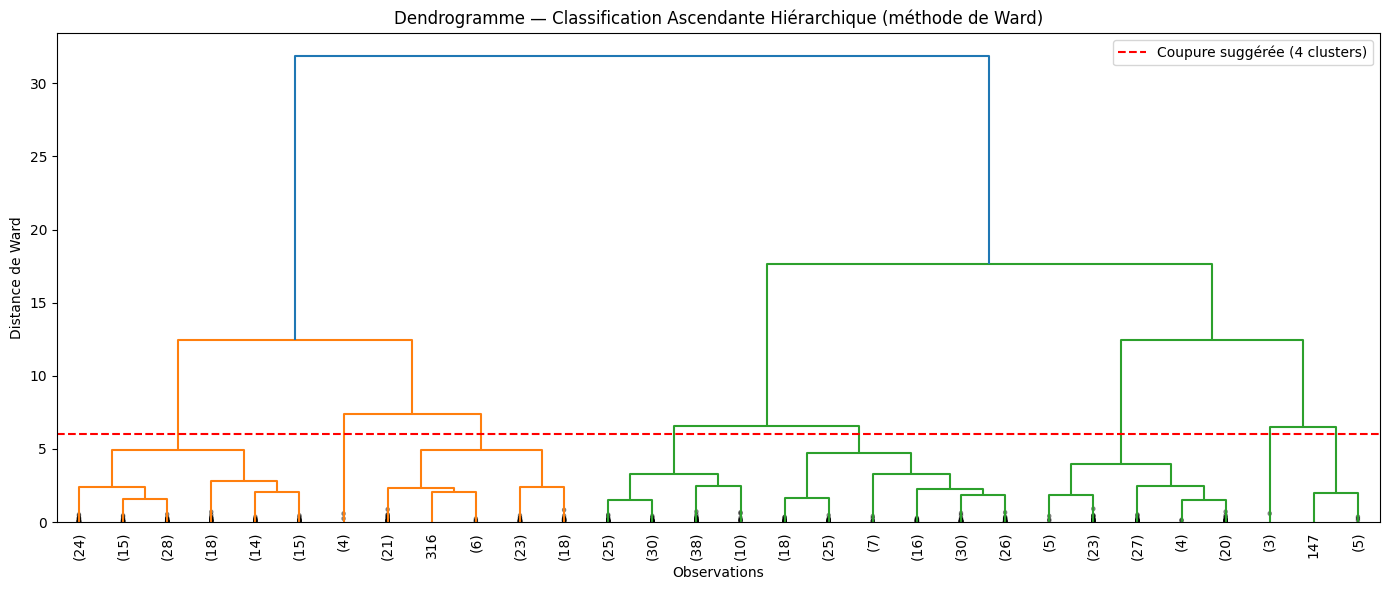

In [15]:
# Calcul de la matrice de liens avec la méthode de Ward
# Ward minimise la variance intra-cluster à chaque fusion
Z = linkage(X_cah_scaled, method='ward')

# Affichage du dendrogramme
plt.figure(figsize=(14, 6))
dendrogram(
    Z,
    truncate_mode='lastp',   # afficher uniquement les 30 dernières fusions
    p=30,
    leaf_rotation=90,
    leaf_font_size=10,
    show_contracted=True
)
plt.title("Dendrogramme — Classification Ascendante Hiérarchique (méthode de Ward)")
plt.xlabel("Observations")
plt.ylabel("Distance de Ward")
plt.axhline(y=6, color='red', linestyle='--', label='Coupure suggérée (4 clusters)')
plt.legend()
plt.tight_layout()
plt.show()

### Interprétation

Le **dendrogramme** représente la hiérarchie des fusions successives entre groupes. Chaque nœud correspond à la fusion de deux clusters, et la hauteur du nœud indique la distance entre eux.

- La **ligne rouge pointillée** représente le niveau de coupure suggéré.
- On coupe là où les **sauts de distance sont les plus grands**, ce qui indique des clusters bien séparés.
- D'après le dendrogramme, une coupure en **4 clusters** semble appropriée, ce qui est cohérent avec le résultat de la méthode du coude pour K-Means.

### <font color='green'>  Assignation des clusters</font>

In [16]:
# Couper le dendrogramme pour obtenir 4 clusters
labels_cah = fcluster(Z, t=4, criterion='maxclust')

# Afficher les étiquettes de cluster assignées
labels_cah

array([2, 3, 1, 3, 2, 2, 2, 1, 2, 3, 2, 2, 2, 2, 2, 1, 2, 2, 2, 3, 2, 3,
       2, 2, 2, 2, 2, 2, 3, 2, 2, 4, 2, 2, 2, 3, 1, 2, 2, 2, 3, 2, 2, 1,
       4, 2, 2, 2, 1, 1, 3, 3, 1, 1, 2, 2, 2, 2, 1, 3, 2, 2, 2, 1, 2, 1,
       2, 2, 1, 1, 2, 1, 1, 1, 1, 3, 3, 1, 2, 2, 1, 1, 3, 1, 2, 3, 1, 2,
       2, 1, 2, 1, 3, 2, 1, 1, 1, 2, 1, 1, 2, 1, 1, 2, 3, 1, 2, 2, 2, 2,
       1, 1, 1, 4, 2, 3, 1, 2, 3, 1, 1, 2, 3, 2, 3, 3, 1, 2, 1, 1, 1, 1,
       1, 3, 1, 3, 2, 2, 2, 2, 3, 1, 1, 3, 2, 1, 2, 4, 2, 2, 2, 3, 3, 1,
       2, 1, 3, 2, 3, 1, 3, 2, 2, 2, 3, 2, 2, 1, 1, 2, 2, 2, 2, 1, 1, 2,
       1, 2, 2, 2, 1, 1, 2, 2, 1, 1, 1, 3, 2, 2, 1, 2, 2, 2, 3, 2, 2, 2,
       1, 3, 2, 2, 1, 3, 3, 2, 1, 1, 2, 1, 2, 1, 2, 2, 1, 2, 2, 3, 1, 2,
       1, 3, 1, 2, 1, 2, 1, 2, 2, 2, 2, 2, 2, 1, 1, 2, 1, 3, 3, 1, 1, 1,
       1, 3, 2, 2, 1, 2, 2, 2, 1, 2, 1, 1, 2, 3, 2, 4, 2, 3, 1, 2, 2, 1,
       2, 1, 3, 1, 2, 1, 1, 1, 3, 2, 2, 2, 2, 3, 1, 2, 2, 2, 1, 2, 2, 1,
       1, 2, 3, 2, 1, 2, 1, 1, 1, 2, 4, 3, 2, 2, 2,

In [17]:
# Trier les indices par numéro de cluster
idk_cah = np.argsort(labels_cah)
idk_cah

array([386, 373, 372, 371, 159, 364, 362, 167, 168, 355, 354, 173, 174,
       352, 176, 350, 349, 180, 181, 347, 184, 185, 186, 343, 190, 342,
       155, 341, 153, 376, 400, 398, 119, 120, 397, 396, 395, 394, 126,
       392, 128, 129, 130, 131, 132, 391, 134, 390, 389, 141, 142, 145,
       380, 379, 377, 375, 116, 337, 335, 306, 239, 240, 241, 242, 305,
       246, 498, 250, 252, 253, 294, 293, 292, 260, 290, 263, 265, 286,
       267, 285, 269, 270, 271, 282, 236, 336, 234, 315, 198, 334, 332,
       202, 331, 330, 329, 206, 207, 209, 327, 211, 326, 325, 214, 324,
       218, 321, 220, 320, 222, 224, 318, 226, 316, 233, 401, 278, 404,
       444,  48,  49, 443, 442,  52,  53, 441,  58, 448,  63, 430,  68,
        69,  71,  72,  73,  74, 427, 426,  65,  77,  43, 450, 497,   2,
       496, 495,   7, 486,  15, 479, 475, 449, 474, 472, 469, 468, 467,
       465, 462,  36, 455, 454, 473, 424, 440,  98,  94,  95,  91,  86,
       408, 420, 101, 407,  96, 414, 110, 423, 111,  81,  80, 41

In [18]:
# Réorganiser le DataFrame selon l'ordre des clusters
df_cah_clust = pd.DataFrame(df_cah.index[idk_cah], labels_cah[idk_cah])
df_cah_clust

,0
1,386
1,373
1,372
1,371
1,159
...,...
4,44
4,296
4,314
4,458


In [19]:
# Calculer les centroïdes (moyennes) de chaque cluster dans l'espace d'origine
df_cah['cluster'] = labels_cah
df_cah.groupby('cluster')[['odometer', 'sellingprice']].mean().round(2)

,odometer,sellingprice
cluster,,
1,131962.55,5631.55
2,38179.45,13742.58
3,27862.00,26593.67
4,15578.11,58572.33


### Interprétation

Après coupure à **4 clusters**, on retrouve des groupes cohérents :
- **Cluster 1** : véhicules très kilométrés à faible prix de vente.
- **Cluster 2** : véhicules avec kilométrage modéré et prix intermédiaire.
- **Cluster 3** : véhicules peu kilométrés à prix élevé.
- **Cluster 4** : véhicules atypiques (outliers) à prix très élevé ou kilométrage extrême.

Les centroïdes confirment la séparation entre les groupes.

### <font color='green'>  Visualisation des clusters CAH</font>

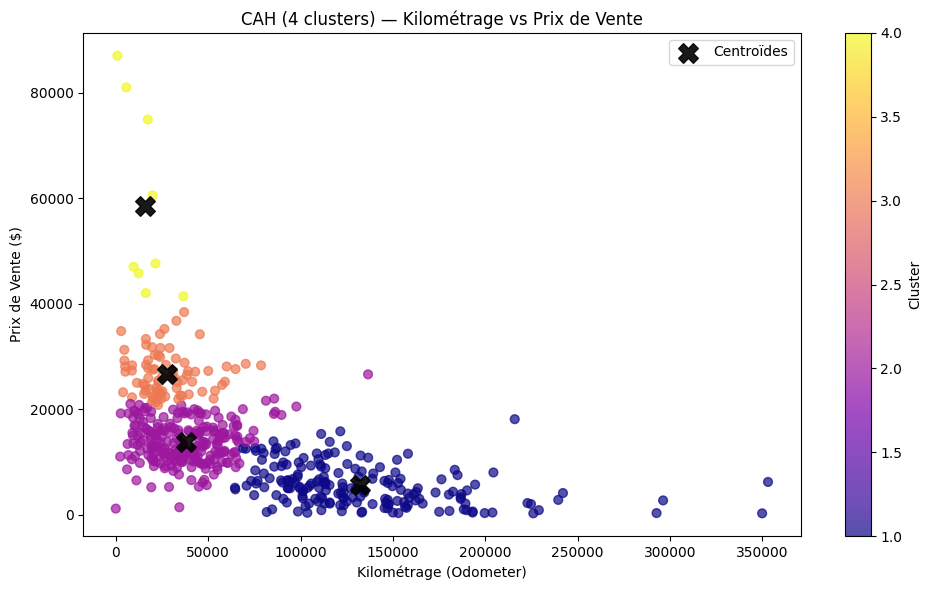

In [20]:
# Visualisation des clusters obtenus par la CAH
plt.figure(figsize=(10, 6))
scatter = plt.scatter(
    df_cah['odometer'],
    df_cah['sellingprice'],
    c=labels_cah,
    cmap='plasma',
    s=40,
    alpha=0.7
)
plt.colorbar(scatter, label='Cluster')

# Afficher les centroïdes
centroids = df_cah.groupby('cluster')[['odometer', 'sellingprice']].mean().values
plt.scatter(
    centroids[:, 0], centroids[:, 1],
    c='black', s=200, marker='X', label='Centroïdes', alpha=0.9
)

plt.title("CAH (4 clusters) — Kilométrage vs Prix de Vente")
plt.xlabel("Kilométrage (Odometer)")
plt.ylabel("Prix de Vente ($)")
plt.legend()
plt.tight_layout()
plt.show()

### Interprétation

Le nuage de points coloré par cluster montre que la CAH sépare bien les véhicules selon leur kilométrage et leur prix de vente, avec des frontières naturelles entre les groupes.

Contrairement à K-Means, la CAH **ne nécessite pas de spécifier K à l'avance** : le nombre de clusters est déterminé a posteriori en coupant le dendrogramme. Cela la rend plus flexible mais aussi plus coûteuse en calcul.

### <font color='green'>  Comparaison visuelle : K-Means vs CAH</font>

D:\Anaconda\Lib\site-packages\sklearn\cluster\_kmeans.py:1425: UserWarning: KMeans is known to have a memory leak on Windows with MKL, when there are less chunks than available threads. You can avoid it by setting the environment variable OMP_NUM_THREADS=2.
  warnings.warn(


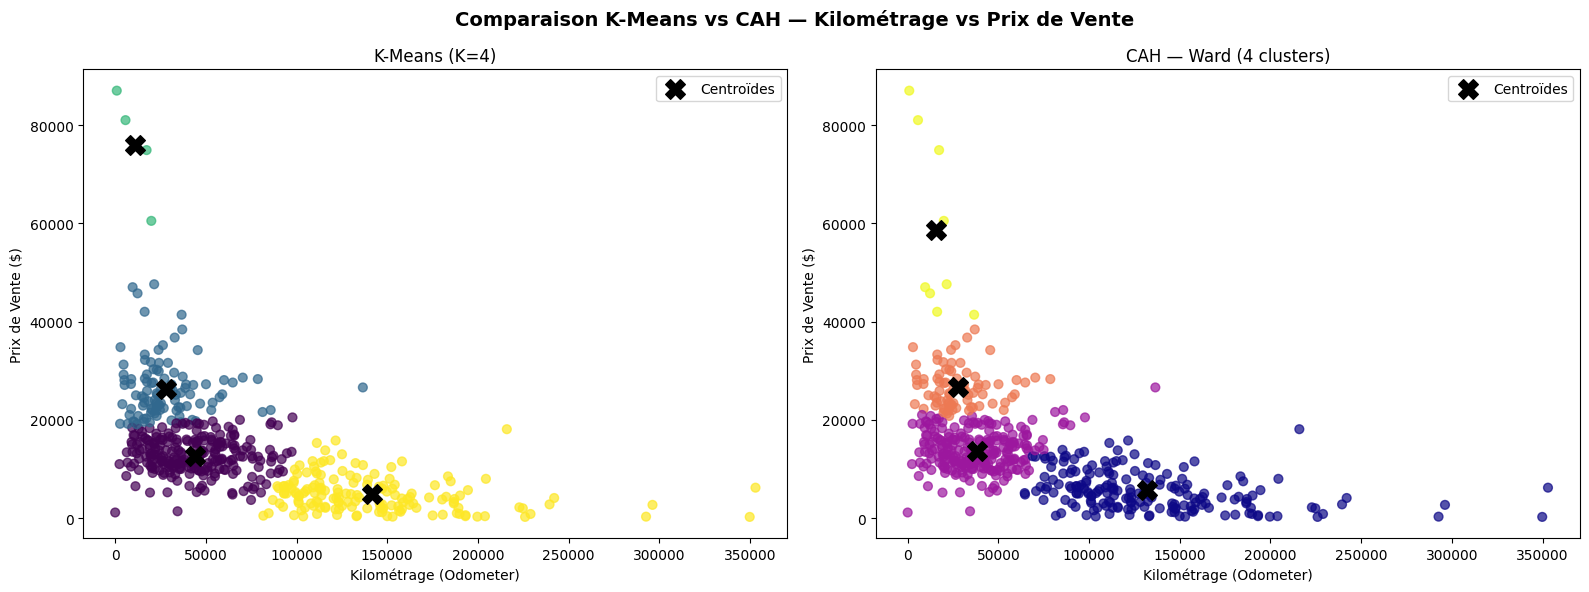

In [21]:
# Appliquer K-Means sur le même sous-échantillon pour comparaison directe
from sklearn.cluster import KMeans

kmeans_cmp = KMeans(n_clusters=4, random_state=0, n_init=10)
labels_km_cmp = kmeans_cmp.fit_predict(X_cah_scaled)

# Affichage côte à côte
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# --- K-Means ---
axes[0].scatter(df_cah['odometer'], df_cah['sellingprice'],
                c=labels_km_cmp, cmap='viridis', s=40, alpha=0.7)
centers_km = scaler.inverse_transform(kmeans_cmp.cluster_centers_)
axes[0].scatter(centers_km[:, 0], centers_km[:, 1],
                c='black', s=200, marker='X', label='Centroïdes')
axes[0].set_title("K-Means (K=4)")
axes[0].set_xlabel("Kilométrage (Odometer)")
axes[0].set_ylabel("Prix de Vente ($)")
axes[0].legend()

# --- CAH ---
axes[1].scatter(df_cah['odometer'], df_cah['sellingprice'],
                c=labels_cah, cmap='plasma', s=40, alpha=0.7)
axes[1].scatter(centroids[:, 0], centroids[:, 1],
                c='black', s=200, marker='X', label='Centroïdes')
axes[1].set_title("CAH — Ward (4 clusters)")
axes[1].set_xlabel("Kilométrage (Odometer)")
axes[1].set_ylabel("Prix de Vente ($)")
axes[1].legend()

plt.suptitle("Comparaison K-Means vs CAH — Kilométrage vs Prix de Vente",
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Interprétation de la Comparaison

| Critère | K-Means | CAH (Ward) |
|---|---|---|
| **Choix de K** | À fixer avant l'entraînement | Déterminé après via le dendrogramme |
| **Type de clusters** | Sphériques, de taille similaire | Formes variées, hiérarchiques |
| **Scalabilité** | Très rapide sur grands datasets | Coûteux en mémoire (matrice n×n) |
| **Reproductibilité** | Dépend de l'initialisation | Déterministe |
| **Interprétabilité** | Centroïdes clairs | Dendrogramme riche en information |

**Conclusion :** Les deux méthodes identifient des segments similaires sur ce dataset. K-Means est préférable pour de grands volumes de données, tandis que la CAH est utile quand on souhaite **explorer la structure hiérarchique** des données sans connaître K à l'avance.